In [47]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [48]:
with open('data/gs_single.pkl', 'rb') as f:
    gs_single = pickle.load(f)

In [49]:
def build_grid(data, metric, kernel_val, normalized_val):
    """Average metric over folds for a given kernel + normalized setting, return 2-D grid (s x p)."""
    s_arr  = np.asarray(data['params']['s'])
    p_arr  = np.asarray(data['params']['p'])
    nm_arr = np.asarray(data['params']['normalized'])
    k_arr  = np.asarray(data['params']['kernel'])
    acc    = np.asarray(data['results'][metric], dtype=float)

    mask = (nm_arr == normalized_val) & (k_arr == kernel_val)
    s_m, p_m, acc_m = s_arr[mask], p_arr[mask], acc[mask]

    su = np.unique(s_m)
    pu = np.unique(p_m)

    # group by (s, p) and mean over folds
    idx = np.lexsort((p_m, s_m))
    s_s, p_s, acc_s = s_m[idx], p_m[idx], acc_m[idx]
    chg = (s_s[1:] != s_s[:-1]) | (p_s[1:] != p_s[:-1])
    starts = np.r_[0, np.flatnonzero(chg) + 1]
    means  = np.add.reduceat(acc_s, starts) / np.diff(np.r_[starts, acc_s.size])

    grid = np.full((su.size, pu.size), np.nan)
    si = np.searchsorted(su, s_s[starts])
    pi = np.searchsorted(pu, p_s[starts])
    grid[si, pi] = means
    return grid, su, pu

## Single-odour gridsearch (`gs_single`)

Parameters swept:
- **s** – fraction of HD neurons that are active (top-k sparsity)
- **p** – Bernoulli sampling probability applied during online weight update
- **kernel** – `top` (top-k) or `rank` (rank-order)
- **normalized** – `raw`, `min-max`, `normalized`, `whitened`

Each cell shows the mean test accuracy averaged over 10 folds.

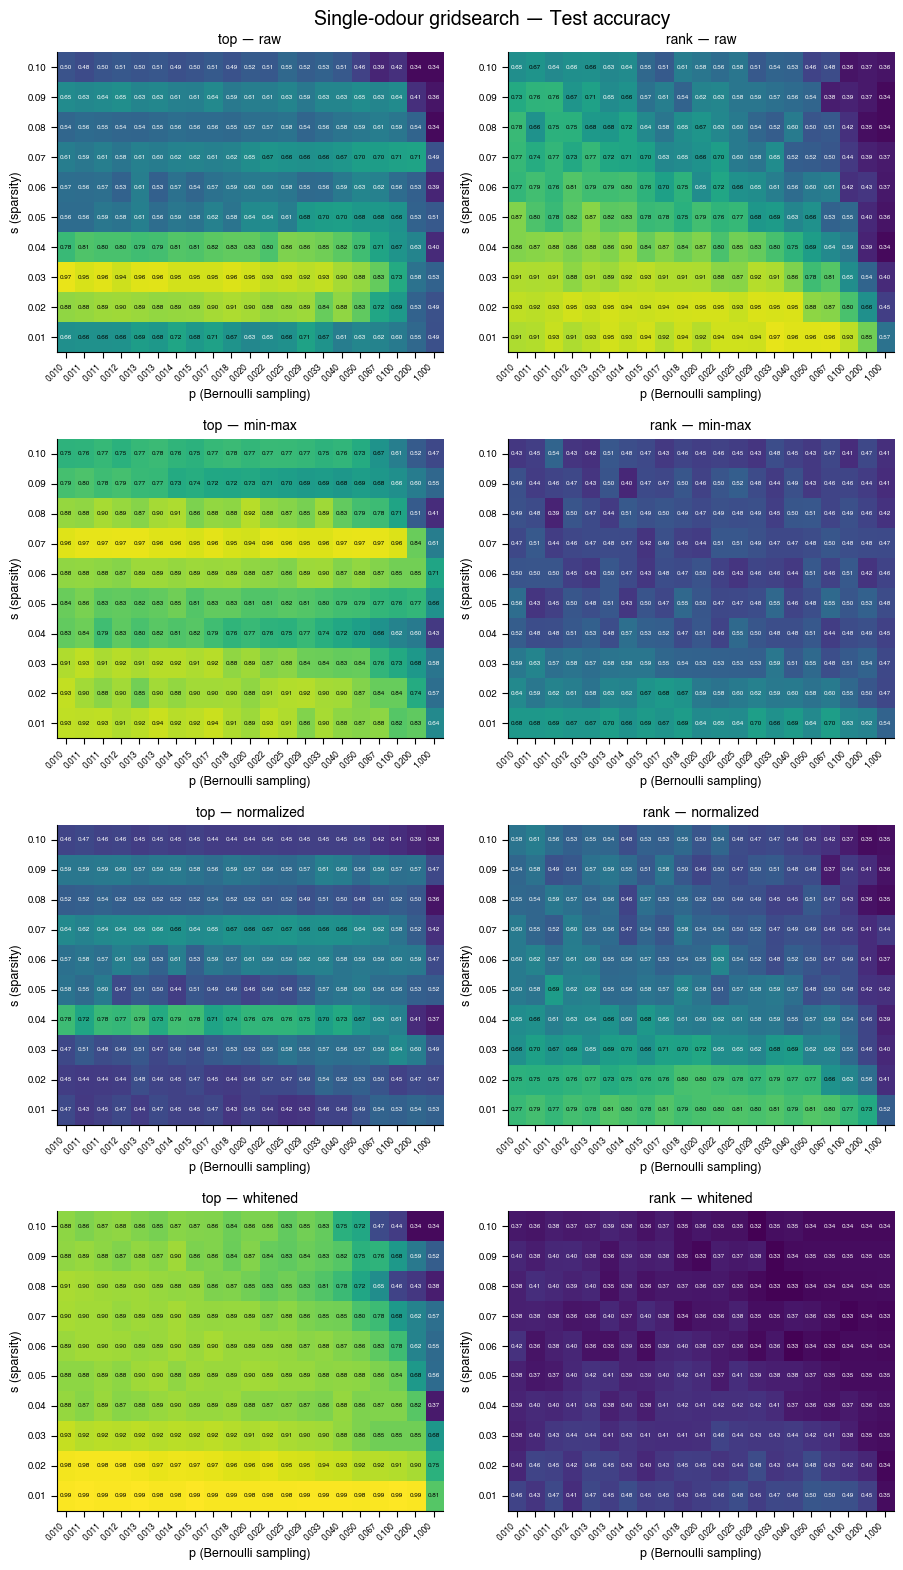

In [50]:
kernels    = ['top', 'rank']
norm_vals  = ['raw', 'min-max', 'normalized', 'whitened']

fig, axes = plt.subplots(len(norm_vals), len(kernels), figsize=(10, 16))
fig.suptitle('Single-odour gridsearch — Test accuracy', fontsize=14, fontweight='bold')

# global colour scale
all_grids = [build_grid(gs_single, 'test_acc', k, n)[0] for k in kernels for n in norm_vals]
vmin = np.nanmin([g.min() for g in all_grids])
vmax = np.nanmax([g.max() for g in all_grids])

for row, nv in enumerate(norm_vals):
    for col, kernel in enumerate(kernels):
        ax = axes[row, col]
        grid, su, pu = build_grid(gs_single, 'test_acc', kernel, nv)

        im = ax.imshow(
            grid, aspect='auto', origin='lower',
            vmin=vmin, vmax=vmax, cmap='viridis'
        )

        ax.set_xticks(np.arange(pu.size))
        ax.set_xticklabels([f'{v:.3f}' for v in pu], rotation=45, ha='right', fontsize=6)
        ax.set_yticks(np.arange(su.size))
        ax.set_yticklabels([f'{v:.2f}' for v in su], fontsize=7)
        ax.set_xlabel('p (Bernoulli sampling)', fontsize=9)
        ax.set_ylabel('s (sparsity)', fontsize=9)
        ax.set_title(f'{kernel} — {nv}', fontsize=10)

        # annotate cells
        thresh = (vmin + vmax) / 2
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                if np.isfinite(grid[i, j]):
                    color = 'white' if grid[i, j] < thresh else 'black'
                    ax.text(j, i, f'{grid[i, j]:.2f}',
                            ha='center', va='center', fontsize=4.5, color=color)

fig.subplots_adjust(right=0.92)
plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

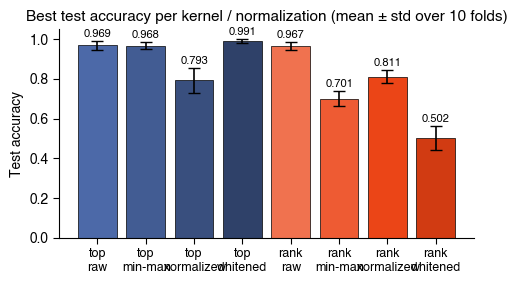

In [51]:
# Bar plot: best test accuracy per kernel x normalization
import matplotlib.colors as mcolors

kernels   = ['top', 'rank']
norm_vals = ['raw', 'min-max', 'normalized', 'whitened']
hue_shifts = [0.0, -0.06, -0.12, -0.18]  # darken/shift per normalization

acc    = np.asarray(gs_single['results']['test_acc'], dtype=float)
s_arr  = np.asarray(gs_single['params']['s'])
p_arr  = np.asarray(gs_single['params']['p'])
nm_arr = np.asarray(gs_single['params']['normalized'])
k_arr  = np.asarray(gs_single['params']['kernel'])

# build base colours in HLS and shift lightness per normalization
base_rgb = {'top': mcolors.to_rgb('C0'), 'rank': mcolors.to_rgb('C1')}

def shift_color(rgb, amount):
    """Shift lightness of an RGB colour."""
    import colorsys
    h, l, s = colorsys.rgb_to_hls(*rgb)
    l = np.clip(l + amount, 0.25, 0.85)
    return colorsys.hls_to_rgb(h, l, s)

labels, means, stds, colors = [], [], [], []
for kernel in kernels:
    for j, nv in enumerate(norm_vals):
        mask = (nm_arr == nv) & (k_arr == kernel)
        s_m, p_m, acc_m = s_arr[mask], p_arr[mask], acc[mask]

        idx = np.lexsort((p_m, s_m))
        s_s, p_s, acc_s = s_m[idx], p_m[idx], acc_m[idx]
        chg = (s_s[1:] != s_s[:-1]) | (p_s[1:] != p_s[:-1])
        starts = np.r_[0, np.flatnonzero(chg) + 1]
        fold_means = np.add.reduceat(acc_s, starts) / np.diff(np.r_[starts, acc_s.size])

        best = int(np.nanargmax(fold_means))
        best_s, best_p = s_s[starts[best]], p_s[starts[best]]
        best_vals = acc_m[(s_m == best_s) & (p_m == best_p)]

        labels.append(f'{kernel}\n{nv}')
        means.append(np.mean(best_vals))
        stds.append(np.std(best_vals))
        colors.append(shift_color(base_rgb[kernel], hue_shifts[j]))

means, stds = np.array(means), np.array(stds)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x, means, yerr=stds, capsize=4, color=colors, edgecolor='k', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Test accuracy')
ax.set_title('Best test accuracy per kernel / normalization (mean ± std over 10 folds)', fontsize=11)
ax.set_ylim(0, 1.05)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.01, f'{m:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [52]:
# Best params summary (test accuracy)
acc    = np.asarray(gs_single['results']['test_acc'], dtype=float)
s_arr  = np.asarray(gs_single['params']['s'])
p_arr  = np.asarray(gs_single['params']['p'])
nm_arr = np.asarray(gs_single['params']['normalized'])
k_arr  = np.asarray(gs_single['params']['kernel'])

for kernel in ['top', 'rank']:
    for nv in ['raw', 'min-max', 'normalized', 'whitened']:
        mask = (nm_arr == nv) & (k_arr == kernel)
        s_m, p_m, acc_m = s_arr[mask], p_arr[mask], acc[mask]

        idx = np.lexsort((p_m, s_m))
        s_s, p_s, acc_s = s_m[idx], p_m[idx], acc_m[idx]
        chg = (s_s[1:] != s_s[:-1]) | (p_s[1:] != p_s[:-1])
        starts = np.r_[0, np.flatnonzero(chg) + 1]
        means  = np.add.reduceat(acc_s, starts) / np.diff(np.r_[starts, acc_s.size])

        best = int(np.nanargmax(means))
        best_s = s_s[starts[best]]
        best_p = p_s[starts[best]]

        bp_mask = (s_m == best_s) & (p_m == best_p)
        best_vals = acc_m[bp_mask]

        print(
            f'[{kernel} | {nv}] Best: s={best_s:.3f}, p={best_p:.4f}  '
            f'mean={np.mean(best_vals):.4f} \u00b1 {np.std(best_vals):.4f}  '
            f'max={np.max(best_vals):.4f}'
        )

[top | raw] Best: s=0.030, p=0.0100  mean=0.9687 ± 0.0209  max=1.0000
[top | min-max] Best: s=0.070, p=0.0125  mean=0.9680 ± 0.0188  max=0.9933
[top | normalized] Best: s=0.040, p=0.0125  mean=0.7927 ± 0.0615  max=0.8867
[top | whitened] Best: s=0.010, p=0.1000  mean=0.9907 ± 0.0095  max=1.0000
[rank | raw] Best: s=0.010, p=0.0333  mean=0.9667 ± 0.0186  max=0.9867
[rank | min-max] Best: s=0.010, p=0.0286  mean=0.7013 ± 0.0391  max=0.7933
[rank | normalized] Best: s=0.010, p=0.0133  mean=0.8113 ± 0.0323  max=0.8600
[rank | whitened] Best: s=0.010, p=0.0500  mean=0.5020 ± 0.0592  max=0.6133


## Gridsearch `gs_single_2` — HD sampling probability (extended)

Fixed: `kernel=top`, `p=0.01`.  
Swept: **s** (sparsity) × **p_hd** (HD Bernoulli sampling probability), 5 folds.  
Normalization: **raw** and **whitened**.

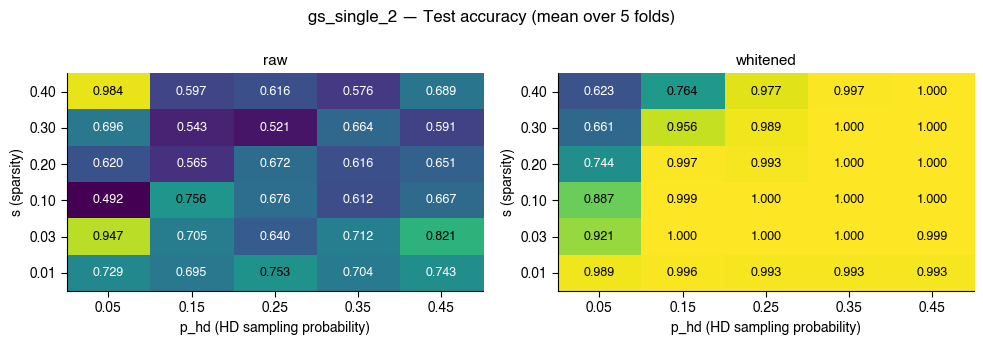

In [55]:
with open('data/gs_single_2.pkl', 'rb') as f:
    gs_single_2 = pickle.load(f)

s_arr   = np.asarray(gs_single_2['params']['s'])
phd_arr = np.asarray(gs_single_2['params']['p_hd'])
nm_arr  = np.asarray(gs_single_2['params']['normalized'])
acc     = np.asarray(gs_single_2['results']['test_acc'], dtype=float)

norm_vals = ['raw', 'whitened']

def build_grid_phd(s_arr, phd_arr, nm_arr, acc, norm_val):
    mask = nm_arr == norm_val
    s_m, ph_m, acc_m = s_arr[mask], phd_arr[mask], acc[mask]
    su, phu = np.unique(s_m), np.unique(ph_m)
    idx = np.lexsort((ph_m, s_m))
    s_s, ph_s, acc_s = s_m[idx], ph_m[idx], acc_m[idx]
    chg = (s_s[1:] != s_s[:-1]) | (ph_s[1:] != ph_s[:-1])
    starts = np.r_[0, np.flatnonzero(chg) + 1]
    means  = np.add.reduceat(acc_s, starts) / np.diff(np.r_[starts, acc_s.size])
    grid = np.full((su.size, phu.size), np.nan)
    grid[np.searchsorted(su, s_s[starts]), np.searchsorted(phu, ph_s[starts])] = means
    return grid, su, phu

grids = {nv: build_grid_phd(s_arr, phd_arr, nm_arr, acc, nv) for nv in norm_vals}
vmin = min(np.nanmin(g[0]) for g in grids.values())
vmax = max(np.nanmax(g[0]) for g in grids.values())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
fig.suptitle('gs_single_2 — Test accuracy (mean over 5 folds)', fontsize=12, fontweight='bold')

for col, nv in enumerate(norm_vals):
    ax = axes[col]
    grid, su, phu = grids[nv]
    im = ax.imshow(grid, aspect='auto', origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(phu.size))
    ax.set_xticklabels([f'{v:.2f}' for v in phu])
    ax.set_yticks(np.arange(su.size))
    ax.set_yticklabels([f'{v:.2f}' for v in su])
    ax.set_xlabel('p_hd (HD sampling probability)')
    ax.set_ylabel('s (sparsity)')
    ax.set_title(nv, fontsize=11)

    thresh = (vmin + vmax) / 2
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if np.isfinite(grid[i, j]):
                color = 'white' if grid[i, j] < thresh else 'black'
                ax.text(j, i, f'{grid[i, j]:.3f}',
                        ha='center', va='center', fontsize=9, color=color)

# fig.colorbar(im, ax=axes, label='Test accuracy', shrink=0.8)
plt.tight_layout()
plt.show()

In [60]:
# Best params summary — gs_single_2
for nv in ['raw', 'whitened']:
    mask = nm_arr == nv
    s_m, ph_m, acc_m = s_arr[mask], phd_arr[mask], acc[mask]

    idx = np.lexsort((ph_m, s_m))
    s_s, ph_s, acc_s = s_m[idx], ph_m[idx], acc_m[idx]
    chg = (s_s[1:] != s_s[:-1]) | (ph_s[1:] != ph_s[:-1])
    starts = np.r_[0, np.flatnonzero(chg) + 1]
    means  = np.add.reduceat(acc_s, starts) / np.diff(np.r_[starts, acc_s.size])

    best = int(np.nanargmax(means))
    best_s, best_ph = s_s[starts[best]], ph_s[starts[best]]
    best_vals = acc_m[(s_m == best_s) & (ph_m == best_ph)]

    print(
        f'[{nv}] Best: s={best_s:.3f}, p_hd={best_ph:.2f}  '
        f'mean={np.mean(best_vals):.4f} ± {np.std(best_vals):.4f}  '
        f'max={np.max(best_vals):.4f}'
    )

[raw] Best: s=0.400, p_hd=0.05  mean=0.9840 ± 0.0172  max=1.0000
[whitened] Best: s=0.030, p_hd=0.15  mean=1.0000 ± 0.0000  max=1.0000
